# Libraries and functions

In [1]:
import torch; torch.set_default_tensor_type(torch.cuda.FloatTensor); import torch.nn as nn; import torch.optim as optim
from gprMax.utilities import detect_check_gpus; from gprMax.gprMax import api; import numpy as np; import h5py; import matplotlib.pyplot as plt; import math
import os; import time; from IPython.display import clear_output; os.getcwd(); import torch; from GPUtil import showUtilization as gpu_usage
from numba import cuda; import gc; import pycuda.driver; import random; import time; import pandas as pd; from scipy.signal import hilbert; import csv
from matplotlib.animation import FuncAnimation; from torch.optim.lr_scheduler import StepLR; from scipy.stats import linregress
plt.rcParams['figure.figsize'] = (10, 2); from bayes_opt import BayesianOptimization; from scipy import stats; import seaborn as sns
def norm(signal):
    signal = np.abs(hilbert(signal))    
    signal = signal/np.max(signal)
    return signal
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from tqdm import tqdm

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


# Data Generation

## 2 Layers

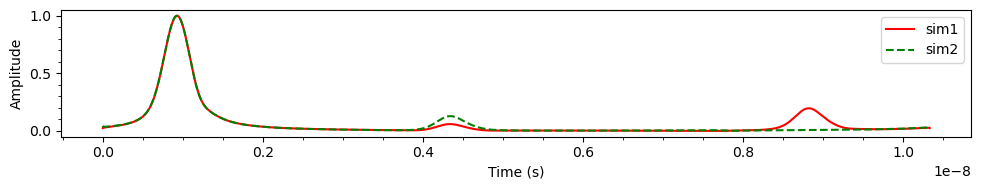

In [ ]:
tw= 10.33e-9;    
def model_miniXT_2D_2Layers(p1,c1, d1, p2, c2,  d2, p_gpr=1.356,c_gpr=0.0012, waveform="gaussian", freq=1.44e9, bs=0.062, dd=0.02):
    b=0.02
    X=0.4; Y=1.0; dx=0.001; Z=dx; gpr_Y = d1+d2+b+dd; freq = freq; Tx=X/2-0.04
    with open("Noise.in", "w") as f:
        f.write(f"#title: Soil_15cm + PEC \n#domain: {X} {Y} {Z}\n#dx_dy_dz: {dx} {dx} {dx}")
        f.write(f"\n#time_window: {tw} \n#material: {p1} {c1} 1 0 mat1  \n#material: {p2} {c2} 1 0 mat2 \n#material: {p_gpr} {c_gpr} 1 0 mat_gpr")
        f.write(f"\n#waveform: {waveform} 1 {freq} my_wave")
        f.write(f"\n#hertzian_dipole: z {Tx} {gpr_Y} 0 my_wave\n#rx: {Tx+bs} {gpr_Y} 0")

        f.write(f"\n#box: 0 {b}         0 {X} {b+d1}            {Z} mat1")        
        f.write(f"\n#box: 0 {b+d1}      0 {X} {b+d1+d2}         {Z} mat2")        
        f.write(f"\n#box: 0 {b+d1+d2}   0 {X} {b+d1+d2 + 2*dd}  {Z} mat_gpr")        

        f.write(f"\n#box: 0 {b-.01} 0 {X} {b} {Z} pec")
        f.write(f"\n#geometry_view: 0 0 0 {X} {Y} {Z} {dx} {dx} {dx} Soil n\n")
        f.close()

    api("Noise.in", geometry_only=False, gpu=[0])
    hf2 = h5py.File("Noise.out", 'r', libver='latest', swmr=True)
    Ascan = hf2['rxs/rx1/Ez'][:]
    hf2.close()
    clear_output()
    return Ascan


sim1 = norm(model_miniXT_2D_2Layers(p1=5, c1=0.01, d1=0.3, p2=3, c2=0.001, d2=0.3));
sim2 = norm(model_miniXT_2D_2Layers(p1=10, c1=0.01, d1=0.3, p2=3, c2=0.001, d2=0.3));

t = np.linspace(0, tw, sim1.shape[0]);  

plt.plot(t,sim1, label='sim1', linestyle='-', color='r')
plt.plot(t,sim2, label='sim2', linestyle='--', color='g')

plt.xlabel('Time (s)'); plt.minorticks_on()
plt.ylabel('Amplitude')
plt.legend(loc='best'); 
plt.tight_layout(); plt.show(); 

In [ ]:
p1_values = np.round(np.arange(3.5, 15.5, 0.5),1)
c1_values = np.round(np.arange(0, 0.14, 0.01),3)
d1_values = np.round(np.arange(0.1, 0.25, 0.05),2)

p2_values = np.round(np.arange(1.0, 4.0, 0.5),1)
c2_values = np.round(np.arange(0, 0.04, 0.01),3)
d2_values = np.round(np.arange(0.1, 0.25, 0.05),2)

p1_values, c1_values, d1_values, p2_values, c2_values, d2_values, len(p1_values)*len(c1_values)*len(d1_values)*len(p2_values)*len(c2_values)*len(d2_values)

(array([ 3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,
         9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5, 13. , 13.5, 14. ,
        14.5, 15. ]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14]),
 array([0.1 , 0.15, 0.2 ]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5]),
 array([0.  , 0.01, 0.02, 0.03]),
 array([0.1 , 0.15, 0.2 ]),
 77760)

In [ ]:
# Generate simulation data 
# Prepare the data with normalized simulation signals
data = []
scan_num = 0
for p1 in p1_values:
    for c1 in c1_values:
        for d1 in d1_values:
            for p2 in p2_values:
                for c2 in c2_values:
                    for d2 in d2_values:
                        sim_signal = norm(model_miniXT_2D_2Layers(p1=p1,c1=c1,d1=d1,p2=p2,c2=c2,d2=d2))
                        data.append([p1, c1, d1, p2, c2, d2] + list(sim_signal))
                        scan_num = scan_num + 1
                        print(f'scan number: {scan_num}')

# Save the data to a CSV file
csv_filename = 'FieldTest_2_layer_SimData_1033.csv'
with open(csv_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    # Write the header
    writer.writerow(['p1', 'c1', 'd1', 'p2', 'c2', 'd2'] + [f'sim_{i}' for i in range(len(sim_signal))])
    # Write the data rows
    writer.writerows(data)

pd.read_csv(csv_filename)

scan number: 77760


,p1,c1,d1,p2,c2,d2,sim_0,sim_1,sim_2,sim_3,...,sim_4371,sim_4372,sim_4373,sim_4374,sim_4375,sim_4376,sim_4377,sim_4378,sim_4379,sim_4380
0,3.5,0.00,0.1,1.0,0.00,0.10,0.023671,0.023890,0.023996,0.024142,...,0.022864,0.022950,0.023049,0.023132,0.023232,0.023310,0.023411,0.023475,0.023578,0.023567
1,3.5,0.00,0.1,1.0,0.00,0.15,0.024709,0.025033,0.025136,0.025316,...,0.024115,0.024189,0.024289,0.024357,0.024458,0.024513,0.024614,0.024640,0.024740,0.024615
2,3.5,0.00,0.1,1.0,0.00,0.20,0.025446,0.025902,0.026000,0.026220,...,0.025182,0.025231,0.025321,0.025360,0.025451,0.025471,0.025563,0.025536,0.025629,0.025361
3,3.5,0.00,0.1,1.0,0.01,0.10,0.023512,0.023607,0.023713,0.023816,...,0.022487,0.022586,0.022685,0.022786,0.022885,0.022988,0.023089,0.023194,0.023296,0.023408
4,3.5,0.00,0.1,1.0,0.01,0.15,0.023808,0.024092,0.024199,0.024366,...,0.023101,0.023181,0.023282,0.023357,0.023459,0.023526,0.023629,0.023674,0.023778,0.023705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77755,15.0,0.14,0.2,3.5,0.02,0.15,0.030798,0.030770,0.030899,0.030977,...,0.029284,0.029422,0.029543,0.029687,0.029810,0.029965,0.030089,0.030266,0.030391,0.030672
77756,15.0,0.14,0.2,3.5,0.02,0.20,0.031325,0.031331,0.031459,0.031548,...,0.029879,0.030011,0.030131,0.030269,0.030391,0.030538,0.030661,0.030826,0.030951,0.031199
77757,15.0,0.14,0.2,3.5,0.03,0.10,0.029358,0.029394,0.029518,0.029614,...,0.028022,0.028146,0.028261,0.028390,0.028507,0.028642,0.028760,0.028908,0.029029,0.029236
77758,15.0,0.14,0.2,3.5,0.03,0.15,0.030200,0.030172,0.030298,0.030374,...,0.028723,0.028857,0.028975,0.029116,0.029235,0.029386,0.029507,0.029679,0.029802,0.030077
